# 01 - Building Feedforward Neural Networks (ANNs) in PyTorch

This notebook provides a comprehensive hands-on guide to constructing, training, and inspecting **Artificial Neural Networks (ANNs)** / **Feedforward Neural Networks (FFNs)** in PyTorch.

---

## Key Learning Objectives:

1. **Core Building Blocks**: Tensors, `nn.Linear` layers, and activation functions.
2. **Model Construction Paradigms**:
   - `nn.Sequential` (quick linear pipelines)
   - `nn.Module` subclassing (modular, object-oriented design)
3. **Loss Functions & Optimizers**: Categorical Cross-Entropy, MSE, and Adam/SGD optimizers.
4. **Training Loop Pipeline**: `zero_grad()`, `forward()`, `loss.backward()`, `optimizer.step()`.
5. **Model Parameter Inspection**: Extracting shapes, weights, biases, and total parameter counts.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as torch_optim
from torch.utils.data import TensorDataset, DataLoader

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Set random seeds for reproducibility
np.random.seed(42)
torch.manual_seed(42)

# Set style
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
print(f"PyTorch Version: {torch.__version__}")


PyTorch Version: 2.11.0+cu128


## 1. Synthetic Dataset Creation & PyTorch Data Loaders

Before building models, we construct a synthetic multi-class classification dataset using `sklearn.datasets.make_classification`. We normalize the features using `StandardScaler` and convert them into PyTorch `TensorDataset` and `DataLoader` instances.


In [2]:
# Generate synthetic 3-class classification data
X_raw, y_raw = make_classification(
    n_samples=1200,
    n_features=20,
    n_informative=15,
    n_redundant=5,
    n_classes=3,
    random_state=42
)

# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(X_raw, y_raw, test_size=0.2, random_state=42)

# Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert to PyTorch Tensors
X_train_t = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.long)
X_test_t = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test_t = torch.tensor(y_test, dtype=torch.long)

# Create PyTorch DataLoaders
train_dataset = TensorDataset(X_train_t, y_train_t)
test_dataset = TensorDataset(X_test_t, y_test_t)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

print(f"Train samples: {len(X_train_t)}, Test samples: {len(X_test_t)}")
print(f"Feature matrix shape: {X_train_t.shape}, Target shape: {y_train_t.shape}")


Train samples: 960, Test samples: 240
Feature matrix shape: torch.Size([960, 20]), Target shape: torch.Size([960])


## 2. Anatomy of `nn.Linear` Layer

The core building block of an FFN is the fully connected (dense) linear layer:
$$y = x W^T + b$$
where $W \in \mathbb{R}^{\text{out} \times \text{in}}$ and $b \in \mathbb{R}^{\text{out}}$.


In [3]:
# Example Linear Layer: 20 input features -> 64 output features
layer = nn.Linear(in_features=20, out_features=64)

print("Weight Matrix Shape:", layer.weight.shape) # (out_features, in_features)
print("Bias Vector Shape:  ", layer.bias.shape)   # (out_features,)

# Single forward pass through linear layer with sample batch
sample_batch = X_train_t[:5]
layer_output = layer(sample_batch)
print("Input shape: ", sample_batch.shape)
print("Output shape:", layer_output.shape)


Weight Matrix Shape: torch.Size([64, 20])
Bias Vector Shape:   torch.Size([64])
Input shape:  torch.Size([5, 20])
Output shape: torch.Size([5, 64])


## 3. Paradigm 1: Building ANNs with `nn.Sequential`

`nn.Sequential` allows rapid prototyping by stacking layers sequentially in a simple linear pipeline.


In [4]:
# Constructing a 3-Layer Neural Network using nn.Sequential
seq_model = nn.Sequential(
    nn.Linear(20, 64),
    nn.ReLU(),
    nn.Linear(64, 32),
    nn.ReLU(),
    nn.Linear(32, 3) # 3 output logits for 3 classes
)

print(seq_model)


Sequential(
  (0): Linear(in_features=20, out_features=64, bias=True)
  (1): ReLU()
  (2): Linear(in_features=64, out_features=32, bias=True)
  (3): ReLU()
  (4): Linear(in_features=32, out_features=3, bias=True)
)


## 4. Paradigm 2: Building ANNs with `nn.Module` Subclassing

Subclassing `nn.Module` is the industry standard for building custom, modular neural networks. It requires defining:

1. `__init__()`: Initialize layers and sub-modules.
2. `forward(x)`: Define the computation graph execution.


In [5]:
class FeedForwardNN(nn.Module):
    def __init__(self, input_dim=20, hidden_dim1=64, hidden_dim2=32, num_classes=3):
        super(FeedForwardNN, self).__init__()
        
        # Define layers
        self.fc1 = nn.Linear(input_dim, hidden_dim1)
        self.fc2 = nn.Linear(hidden_dim1, hidden_dim2)
        self.fc3 = nn.Linear(hidden_dim2, num_classes)
        
        # Activation functions
        self.relu = nn.ReLU()
        
    def forward(self, x):
        # Layer 1
        x = self.fc1(x)
        x = self.relu(x)
        
        # Layer 2
        x = self.fc2(x)
        x = self.relu(x)
        
        # Layer 3 (Logits)
        out = self.fc3(x)
        return out

# Instantiate model
model = FeedForwardNN(input_dim=20, hidden_dim1=64, hidden_dim2=32, num_classes=3)
print(model)


FeedForwardNN(
  (fc1): Linear(in_features=20, out_features=64, bias=True)
  (fc2): Linear(in_features=64, out_features=32, bias=True)
  (fc3): Linear(in_features=32, out_features=3, bias=True)
  (relu): ReLU()
)


## 5. Loss Function, Optimizer, and Full Training Loop

- **Loss Function**: `nn.CrossEntropyLoss()` combines `LogSoftmax` and `NLLLoss` in one numerically stable class. It accepts raw unnormalized logits.
- **Optimizer**: `torch.optim.Adam` computes adaptive learning rates using first and second moments.
- **Training Step**:
  1. `optimizer.zero_grad()`: Reset accumulated gradients.
  2. `outputs = model(inputs)`: Compute forward pass.
  3. `loss = criterion(outputs, targets)`: Compute loss.
  4. `loss.backward()`: Compute backpropagation gradients $\frac{\partial L}{\partial w}$.
  5. `optimizer.step()`: Update weights $w \leftarrow w - \eta \cdot g$.


In [ ]:
def train_and_evaluate(model, train_loader, test_loader, epochs=50, lr=0.001):
    criterion = nn.CrossEntropyLoss()
    optimizer = torch_optim.Adam(model.parameters(), lr=lr)
    
    history = {'train_loss': [], 'test_loss': [], 'train_acc': [], 'test_acc': []}
    
    for epoch in range(1, epochs + 1):
        # --- Training Phase ---
        model.train()
        running_loss = 0.0
        correct_train = 0
        total_train = 0
        
        for batch_x, batch_y in train_loader:
            optimizer.zero_grad()
            outputs = model(batch_x)
            loss = criterion(outputs, batch_y)
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item() * batch_x.size(0)
            preds = torch.argmax(outputs, dim=1)
            correct_train += (preds == batch_y).sum().item()
            total_train += batch_y.size(0)
            
        epoch_train_loss = running_loss / total_train
        epoch_train_acc = correct_train / total_train
        
        # --- Evaluation Phase ---
        model.eval()
        running_test_loss = 0.0
        correct_test = 0
        total_test = 0
        
        with torch.no_grad():
            for batch_x, batch_y in test_loader:
                outputs = model(batch_x)
                loss = criterion(outputs, batch_y)
                
                running_test_loss += loss.item() * batch_x.size(0)
                preds = torch.argmax(outputs, dim=1)
                correct_test += (preds == batch_y).sum().item()
                total_test += batch_y.size(0)
                
        epoch_test_loss = running_test_loss / total_test
        epoch_test_acc = correct_test / total_test
        
        history['train_loss'].append(epoch_train_loss)
        history['test_loss'].append(epoch_test_loss)
        history['train_acc'].append(epoch_train_acc)
        history['test_acc'].append(epoch_test_acc)
        
        if epoch % 10 == 0 or epoch == 1:
            print(f"Epoch {epoch:02d}/{epochs:02d} | "
                  f"Train Loss: {epoch_train_loss:.4f} | Train Acc: {epoch_train_acc:.4f} | "
                  f"Test Loss: {epoch_test_loss:.4f} | Test Acc: {epoch_test_acc:.4f}")
            
    return history

# Run training
history = train_and_evaluate(model, train_loader, test_loader, epochs=50, lr=0.001)


Epoch 01/50 | Train Loss: 1.0538 | Train Acc: 0.4979 | Test Loss: 1.0109 | Test Acc: 0.5667
Epoch 10/50 | Train Loss: 0.4122 | Train Acc: 0.8615 | Test Loss: 0.5182 | Test Acc: 0.7708
Epoch 20/50 | Train Loss: 0.2203 | Train Acc: 0.9354 | Test Loss: 0.4458 | Test Acc: 0.8208
Epoch 30/50 | Train Loss: 0.1362 | Train Acc: 0.9688 | Test Loss: 0.4589 | Test Acc: 0.8333
Epoch 40/50 | Train Loss: 0.0856 | Train Acc: 0.9844 | Test Loss: 0.4854 | Test Acc: 0.8417
Epoch 50/50 | Train Loss: 0.0511 | Train Acc: 0.9927 | Test Loss: 0.5725 | Test Acc: 0.8375


## 6. Visualizing Training Curves

We plot loss and accuracy trajectories over epochs to assess model convergence.


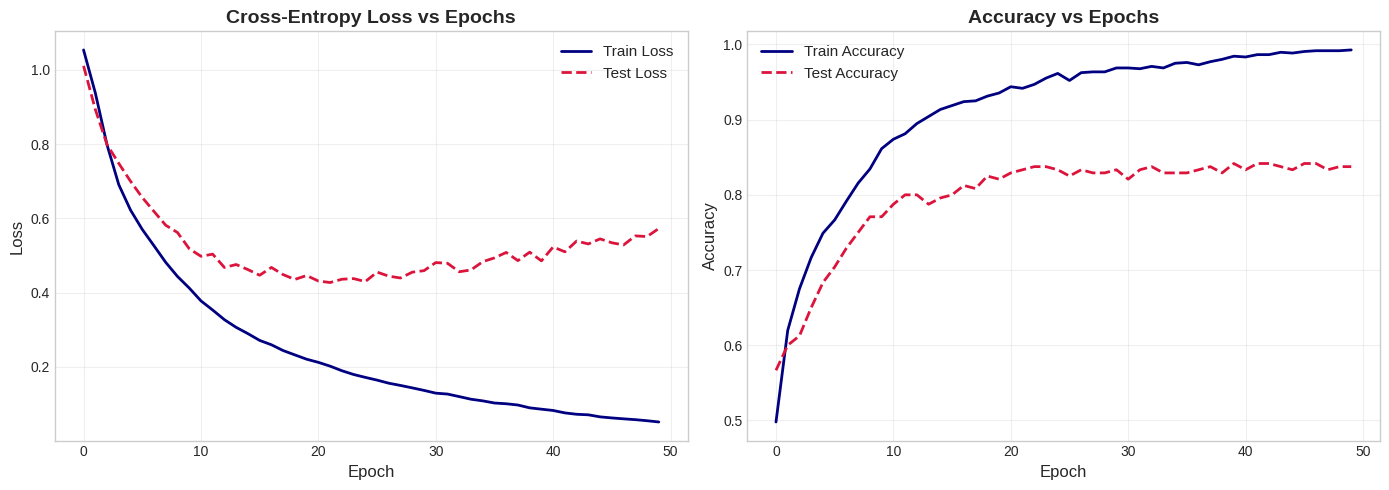

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss Plot
axes[0].plot(history['train_loss'], label='Train Loss', color='navy', linewidth=2)
axes[0].plot(history['test_loss'], label='Test Loss', color='crimson', linewidth=2, linestyle='--')
axes[0].set_title('Cross-Entropy Loss vs Epochs', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Loss', fontsize=12)
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

# Accuracy Plot
axes[1].plot(history['train_acc'], label='Train Accuracy', color='navy', linewidth=2)
axes[1].plot(history['test_acc'], label='Test Accuracy', color='crimson', linewidth=2, linestyle='--')
axes[1].set_title('Accuracy vs Epochs', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Accuracy', fontsize=12)
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## 7. Model Parameter & Weight Inspection

Understanding model complexity involves counting trainable parameters and examining parameter tensors.


In [8]:
def inspect_model(model):
    print("=" * 60)
    print("MODEL PARAMETER SUMMARY")
    print("=" * 60)
    total_params = 0
    for name, param in model.named_parameters():
        if param.requires_grad:
            num_params = param.numel()
            total_params += num_params
            print(f"{name:<25} | Shape: {str(list(param.shape)):<18} | Params: {num_params}")
    print("=" * 60)
    print(f"Total Trainable Parameters: {total_params:,}")
    print("=" * 60)

inspect_model(model)


MODEL PARAMETER SUMMARY
fc1.weight                | Shape: [64, 20]           | Params: 1280
fc1.bias                  | Shape: [64]               | Params: 64
fc2.weight                | Shape: [32, 64]           | Params: 2048
fc2.bias                  | Shape: [32]               | Params: 32
fc3.weight                | Shape: [3, 32]            | Params: 96
fc3.bias                  | Shape: [3]                | Params: 3
Total Trainable Parameters: 3,523
